In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# Simulate data
trend = np.arange(100)
sin = np.sin(np.pi * 2 * trend / 100)
cos = np.cos(np.pi * 2 * trend / 100)
x1 = sin + trend/8
x2 = cos + trend/8

ds_size = 16  # number of datasets
data = []

for i in range(ds_size):
    x_1 = x1 * np.random.rand()
    x_2 = x2 * np.random.rand()
    step_array = np.zeros_like(x_1)
    step_array[40::50] = 1
    x_1 += step_array * (i % 2 == 0)
    x_2 += step_array * (i % 2 != 0)
    data.append(np.stack([x_1, x_2], axis=1))


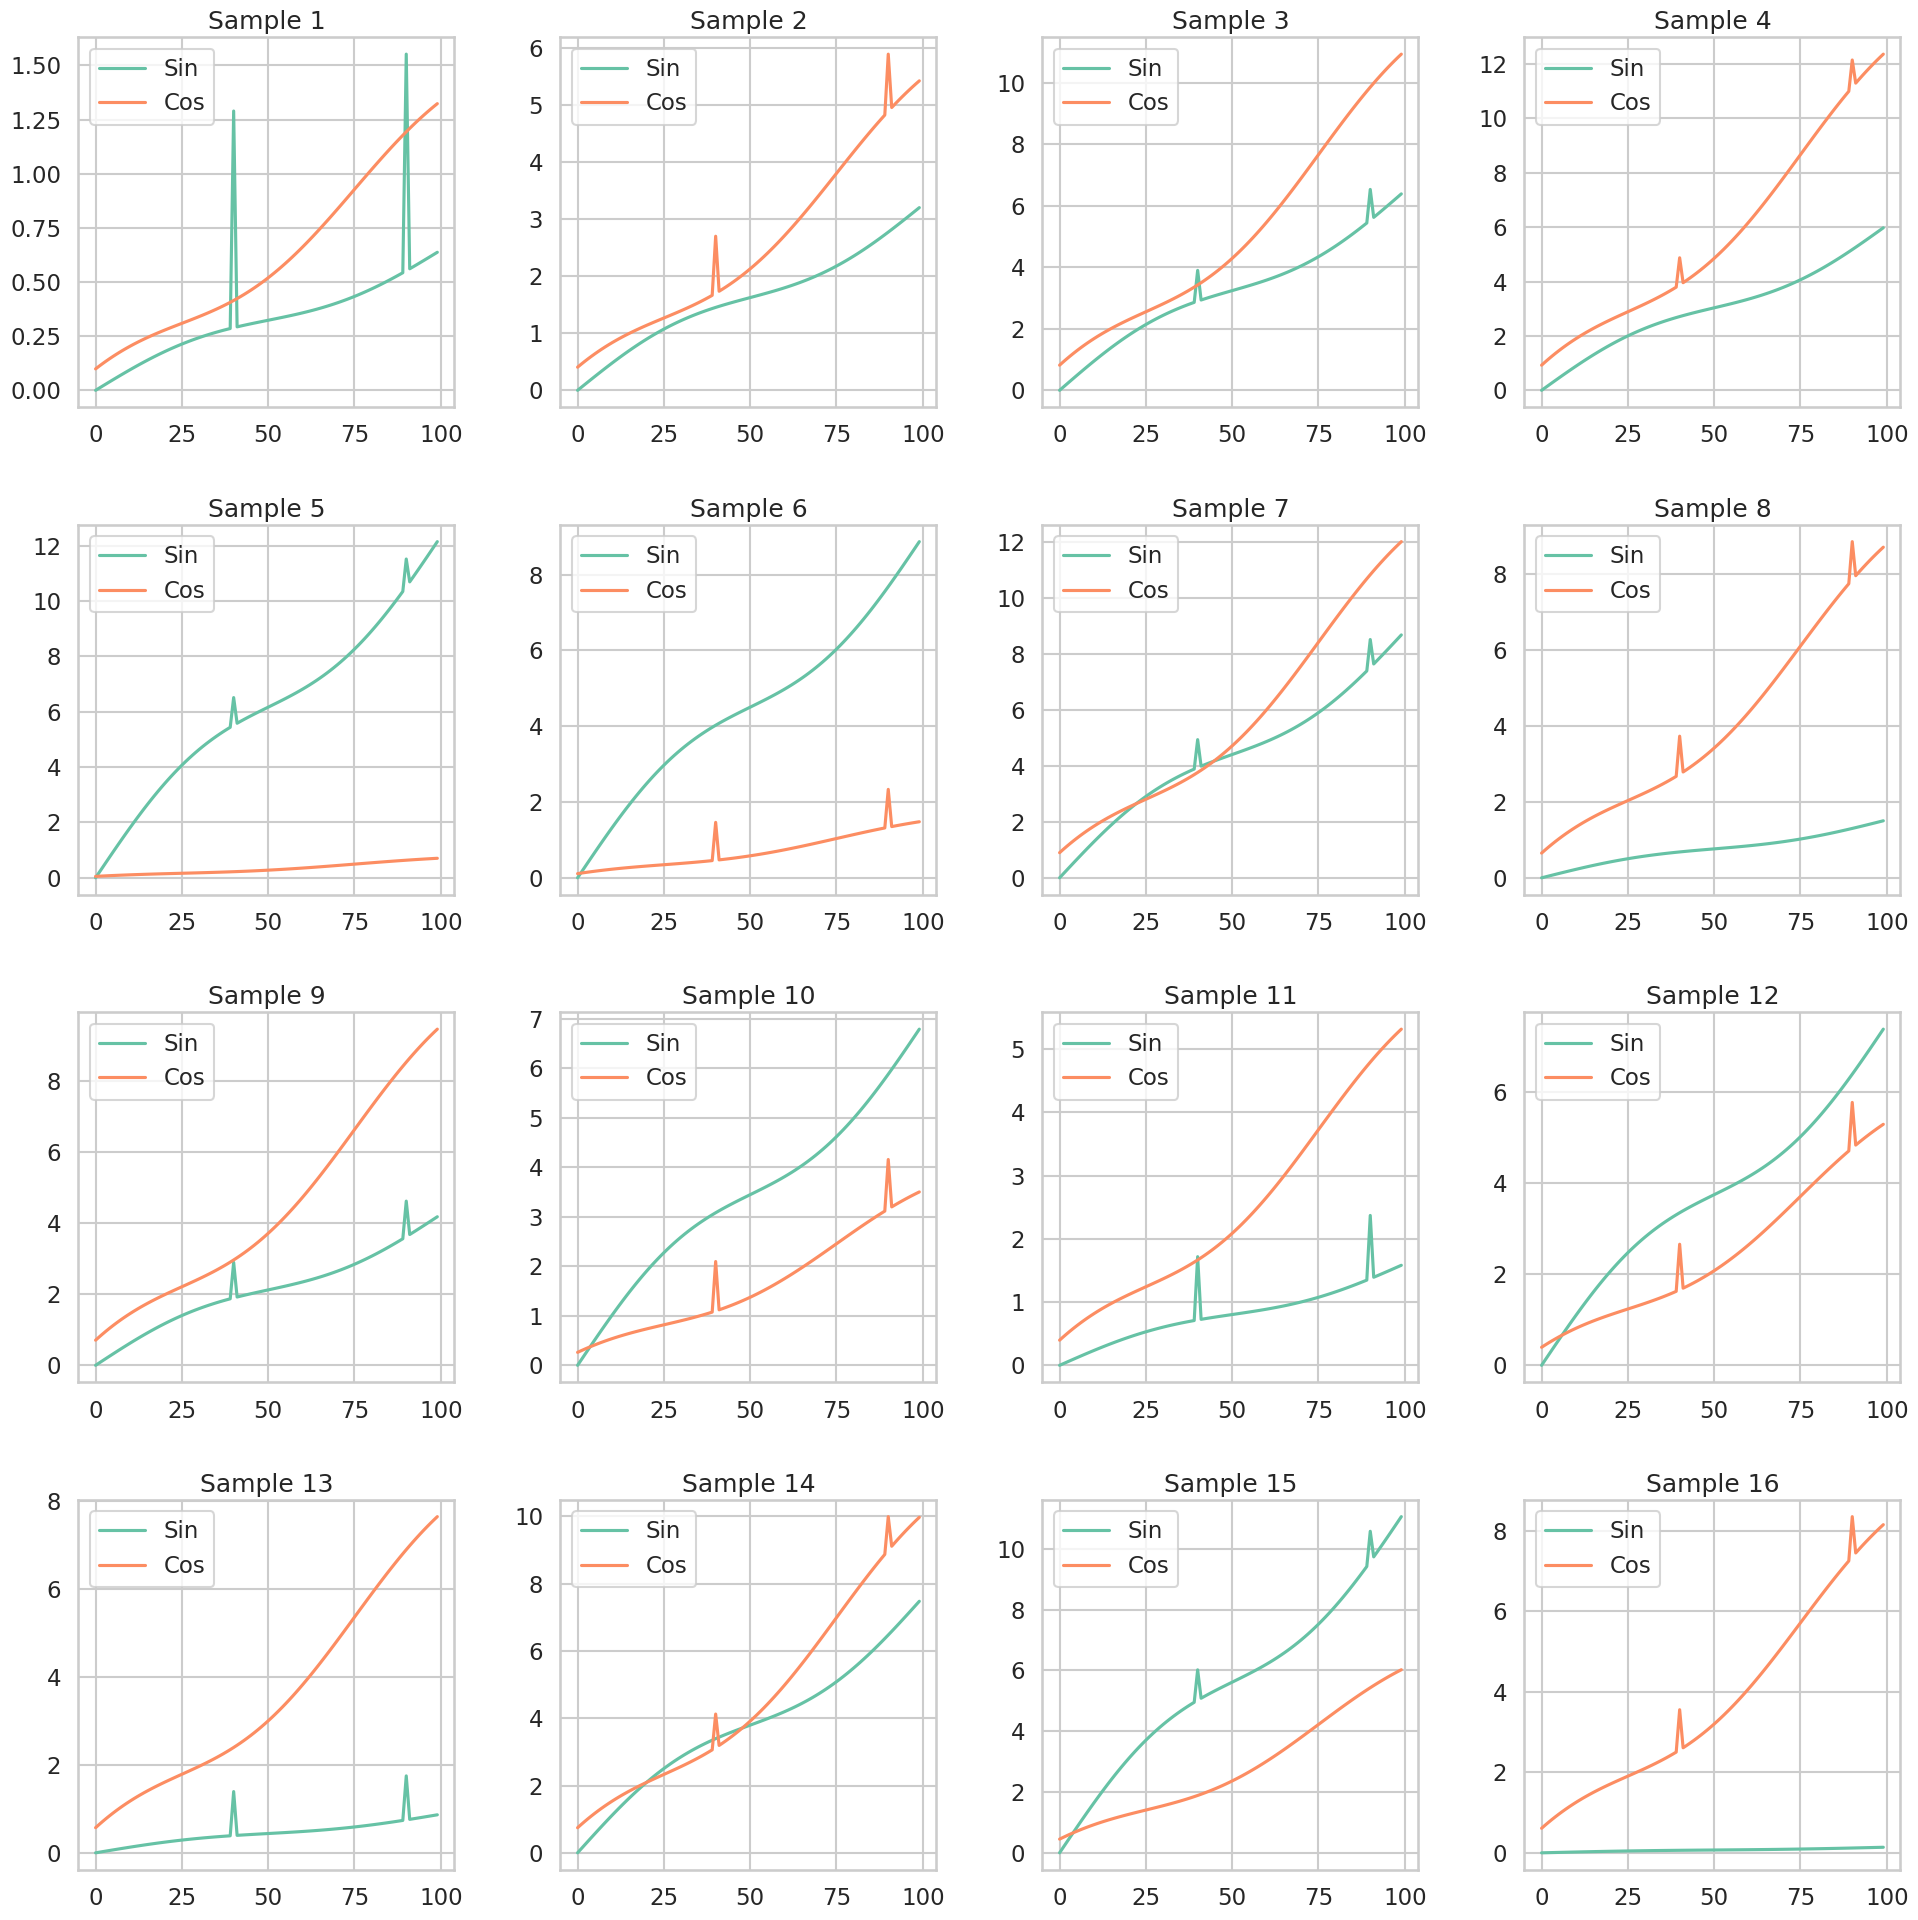

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_grid(x, data):
    """
    Plot a grid of line plots for the given data.

    :param x: The trend values for the x-axis.
    :param data: An array of datasets where each dataset contains two features.
    """
    # Set up Seaborn and Matplotlib aesthetics
    sns.set_theme(style="whitegrid", context="talk")
    palette = sns.color_palette("Set2", 2)

    # Determine the number of rows and columns for the subplot grid
    num_plots = len(data)
    num_cols = min(num_plots, 4)
    num_rows = (num_plots + num_cols - 1) // num_cols

    # Set up the grid of plots
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(5 * num_cols, 5 * num_rows))
    axes = axes.flatten()  # Flatten the grid for easy iteration

    # Use Seaborn's lineplot to plot each dataset
    for i, ax in enumerate(axes):
        if i < num_plots:
            sns.lineplot(x=x, y=data[i][:, 0], ax=ax, label='Sin', color=palette[0])
            sns.lineplot(x=x, y=data[i][:, 1], ax=ax, label='Cos', color=palette[1])
            ax.set_title(f'Sample {i + 1}')
            ax.legend()
        else:
            ax.set_visible(False)  # Hide unused axes

    # Improve plot spacing
    plt.tight_layout(pad=2)  # Adjust padding between plots
    plt.show()

# Example usage with dummy data:
# trend = np.arange(100)
# data = [np.column_stack([np.sin(trend), np.cos(trend)]) for _ in range(16)]
plot_grid(trend, data)


In [5]:
import torch
import torch.nn as nn
t_data = torch.tensor(data).float() # batch length var

seq_len = t_data.shape[1] 
patch_size = 8
stride = patch_size // 2

t_data = t_data.transpose(1, 2)

patch_num = (seq_len - patch_size) // stride + 1

padding_patch_layer = nn.ReplicationPad1d((0, stride)) 

padded_data = padding_patch_layer(t_data)

padded_data.shape

# plot_grid(torch.arange(padded_data.shape[-1]).numpy(), padded_data.transpose(1,2).numpy())


torch.Size([16, 2, 104])

In [18]:
patches = padded_data.unfold(-1, patch_size, stride)
patches.shape
# Batch x Var x PatchNum x PatchSize
# plot one batch sample all patches

a = np.arange(20).reshape(4,5,1)
b  = np.arange(20,40).reshape(4,5,1)
c = np.stack([a,b], axis=1)

from einops import rearrange

rearrange(c, 'b v count s -> b (count v) s')[0]

array([[ 0],
       [20],
       [ 1],
       [21],
       [ 2],
       [22],
       [ 3],
       [23],
       [ 4],
       [24]])

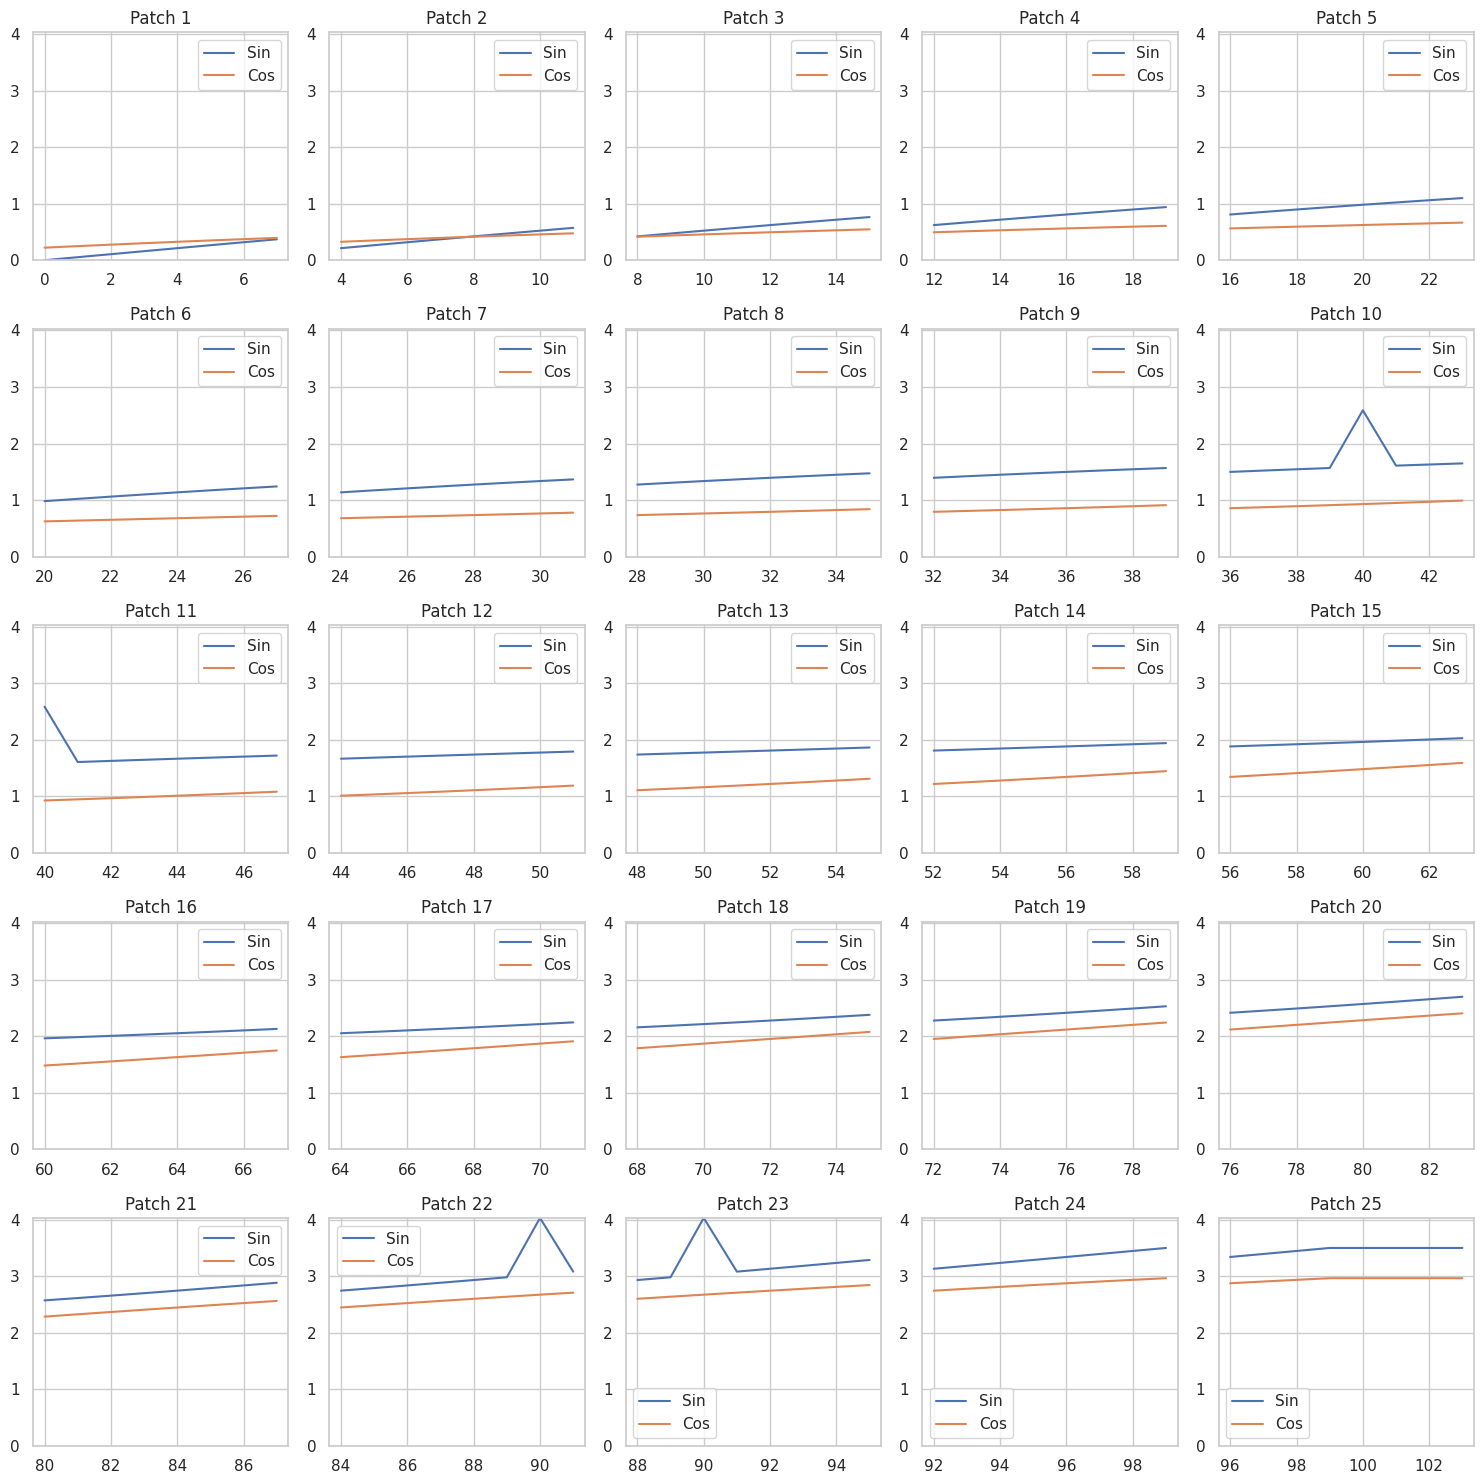

In [58]:
# Set up the plot
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(15, 15))
axes = axes.flatten()

y_min = patches[0].min().item()
y_max = patches[0].max().item()


for i, ax in enumerate(axes):
        ts = np.arange(i*stride,(i+1)*patch_size- i*stride)
        sns.lineplot(x=ts, y=patches[0][0][i].numpy(), ax=ax, label='Sin')
        sns.lineplot(x=ts, y=patches[0][1][i].numpy(), ax=ax, label='Cos')
        ax.set_ylim(y_min, y_max)
        ax.set_title(f'Patch {i + 1}')


plt.tight_layout()
plt.show()

In [62]:
from einops import rearrange

patches_combined = rearrange(patches, 'batch var numpatches patchwidth -> batch numpatches (patchwidth var)')

c_in = patches_combined.shape[-1]
dim_token = 10


tokenConv = nn.Conv1d(in_channels=c_in, out_channels=dim_token,
                                   kernel_size=3, padding=1, padding_mode='circular', bias=False)
# for m in self.modules():
#     if isinstance(m, nn.Conv1d):
#         nn.init.kaiming_normal_(
#             m.weight, mode='fan_in', nonlinearity='leaky_relu')

# def forward(self, x):
#     return x

# tokenConv(patches_combined).shape
x = tokenConv(patches_combined.permute(0, 2, 1)).transpose(1, 2)
x.shape

torch.Size([16, 25, 10])